In [2]:
import gzip
import glob
import csv
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

aa=['GLYD', 'SCP', 'SCA', 'SCV', 'SCL', 'SCI', 'SCC', 'SCM', 'SCS', 'SCT', 'SCN', 'SCQ',
    'SCF', 'SCY', 'SCW', 'SCCM', 'SCYM', 'SCE', 'SCEN', 'SCD',
    'SCDN', 'SCK', 'SCKN', 'SCR', 'SCRN', 'SCHD', 'SCHE', 'SCHP']

save_dir='../plot/'

# Load monomer/multimer rates
_rate_file = '../data/SUPP_monomer/monomer_rates_45A_9batches.dat'
_rate_df = pd.read_csv(_rate_file, sep=r'\s+', comment='#', encoding='latin-1')
monomer_rates  = dict(zip(_rate_df['SC'], _rate_df['mono_mean']))
multimer_rates = dict(zip(_rate_df['SC'], _rate_df['multi_mean']))
print(f'Loaded rates for {len(monomer_rates)} analogs from {_rate_file}')

Loaded rates for 36 analogs from ../data/SUPP_monomer/monomer_rates_45A_9batches.dat


C:\Users\soeur\AppData\Local\Temp\ipykernel_9992\3003213795.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0.03, 1, 1])


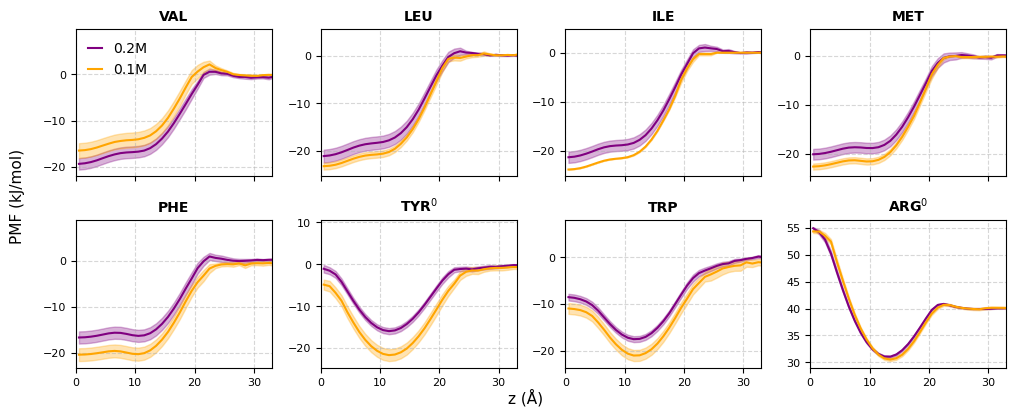

In [4]:
##############################################################################
# PMF mono vs total (using monomer_4.5A and total PMF data)
##############################################################################
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import os

PMF_TOTAL = '../data/pmf_data/total'
PMF_MONO = '../data/pmf_data/monomer_4.5A'
PMF_MULTI = '../data/pmf_data/multimer_4.5A'

def free_energy(pKa, charge):
    R=8.314*10**(-3) #kJ/mol.K
    T=302.3545798089109 #K
    pH=7.0
    return -charge*R*T*np.log(10)*(pKa-pH)

def get_ref_per_acid(acid):
    #source : Platzer et al. (2014)
    neutrals=['SCHP', 'SCKN', 'SCRN', 'SCDN', 'SCEN', 'SCCM', 'SCYM']
    pKas=[6.45, 10.34, 13.9, 3.86, 4.34, 8.49, 9.76]
    charges=[1, -1, -1, 1, 1, -1, -1]
    if acid in neutrals:
        zero_ref=free_energy(pKas[neutrals.index(acid)], charges[neutrals.index(acid)])
    else:
        zero_ref=0
    return zero_ref

def load_pmf_batches(acid, pmf_dir, conc=0.2):
    """
    Load PMF from 3 trajectory files (each with 3 batch columns),
    compute mean + SE over 9 batches. PMF is symmetrized (z >= 0).
    """
    batch_data = []
    for traj in [1, 2, 3]:
        if conc==0.2:
            filepath = os.path.join(pmf_dir, acid.lower(), f'trajectory{traj}.dat')
        elif conc==0.1:
            filepath = os.path.join(pmf_dir, acid.lower()+"-1", f'trajectory{traj}.dat')
        if not os.path.isfile(filepath):
            continue
        df = pd.read_csv(filepath, sep=r'\s+')
        z_col = df.columns[0]
        batch_cols = df.columns[1:]

        for col in batch_cols:
            df_batch = df[[z_col, col]].copy()
            df_batch.columns = ['z', 'pmf']
            df_batch = df_batch.dropna()
            batch_data.append(df_batch)

    if len(batch_data) == 0:
        return None

    # Merge all batches on z
    result = batch_data[0][['z']].copy()
    for i, bd in enumerate(batch_data):
        result = pd.merge(result, bd, on='z', how='outer', suffixes=('', f'_{i}'))
        if i == 0:
            result = result.rename(columns={'pmf': f'pmf_{i}'})

    pmf_cols = [c for c in result.columns if c.startswith('pmf')]
    result['PMF_mean'] = result[pmf_cols].mean(axis=1)
    result['std_error'] = result[pmf_cols].std(axis=1, ddof=1) / np.sqrt(len(pmf_cols))
    return result[['z', 'PMF_mean', 'std_error']].dropna().sort_values('z')


def plot_pmf_mono_vs_total_45A_grid(acid_list, label_list, name, titrable=False,
                                     ncols=4, x_grid_interval=10):
    """
    Grid plot comparing PMF monomer (4.5A) vs PMF total. No percentage scaling.
    """
    n_acids = len(acid_list)
    nrows = int(np.ceil(n_acids / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.2 * nrows),
                              gridspec_kw={'hspace': 0.3, 'wspace': 0.25}, sharex=True)
    axes_flat = axes.flatten()

    for idx, (acid, label) in enumerate(zip(acid_list, label_list)):
        ax = axes_flat[idx]

        data_total = load_pmf_batches(acid, PMF_TOTAL)
        data_total1 = load_pmf_batches(acid, PMF_TOTAL, conc=0.1)
        data_mono = load_pmf_batches(acid, PMF_MONO)

        if titrable:
            correction = get_ref_per_acid(acid)
        else:
            correction = 0
        if data_mono is not None:
            x_m, y_m, e_m = data_mono['z'], data_mono['PMF_mean'] + correction, data_mono['std_error']
            #ax.fill_between(x_m, y_m - e_m, y_m + e_m, alpha=0.3, color='green')
            #ax.plot(x_m, y_m, label='Contact-free', lw=1.5, color='green', linestyle='--')
            #print(e_m)

        if data_total is not None:
            x_t, y_t, e_t = data_total['z'], data_total['PMF_mean'] + correction, data_total['std_error']
            ax.fill_between(x_t, y_t - e_t, y_t + e_t, alpha=0.3, color='purple')
            ax.plot(x_t, y_t, label='0.2M', lw=1.5, color='purple')
            #print(e_t)
        
        if data_total1 is not None:
            x_t1, y_t1, e_t1 = data_total1['z'], data_total1['PMF_mean'] + correction, data_total1['std_error']
            ax.fill_between(x_t1, y_t1 - e_t1, y_t1 + e_t1, alpha=0.3, color='orange')
            ax.plot(x_t1, y_t1, label='0.1M', lw=1.5, color='orange')
            #print(e_t1)


        ax.set_xlim(0, 33)
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.xaxis.set_major_locator(ticker.MultipleLocator(x_grid_interval))
        ax.grid(True, which='major', linestyle='--', alpha=0.5)
        ax.tick_params(axis='both', labelsize=8)

        if idx == 0:
            ax.legend(loc='upper left', fontsize=10, frameon=False, handlelength=1)

    for idx in range(n_acids, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    fig.text(0.5, 0.03, "z (Å)", ha='center', fontsize=11)
    fig.text(0.07, 0.5, "PMF (kJ/mol)", va='center', rotation='vertical', fontsize=11)

    plt.tight_layout(rect=[0.03, 0.03, 1, 1])
    plt.savefig(save_dir + f'{name}.png', bbox_inches='tight', dpi=600)
    plt.show()


# Hydrophobic subset
aa_hydrophobic = ['SCV', 'SCL', 'SCI', 'SCM', 'SCF', 'SCY', 'SCW', 'SCRN']
labels_hydrophobic = ['VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TYR$^0$', 'TRP', 'ARG$^0$']

plot_pmf_mono_vs_total_45A_grid(aa_hydrophobic, labels_hydrophobic,
                                 'FigureS7', titrable=True)

In [8]:
##############################################################################
# Comparison of full PMF curves at 0.2 M and 0.1 M
#
# Test 1: paired t-test on the two mean curves over their common z grid.
# This exploratory test does not account for correlation between nearby z bins.
#
# Test 2: exact global permutation test on whole block curves. Set
# PERMUTATION_BLOCK_NS to 200 for nine batch curves per concentration or to
# 600 for three trajectory-averaged curves per concentration. Set
# PERMUTATION_STATISTIC to 'RMS' or 'SE'. Whole curves are permuted to preserve
# z correlation. Both families of eight p-values use Benjamini-Hochberg FDR.
##############################################################################
from itertools import combinations
from scipy import stats

ALPHA = 0.05
PERMUTATION_BLOCK_NS = 200
PERMUTATION_STATISTIC = 'RMS'
BATCH_BLOCK_NS = 200
BATCHES_PER_TRAJECTORY = 3

if PERMUTATION_BLOCK_NS not in (BATCH_BLOCK_NS, 600):
    raise ValueError('PERMUTATION_BLOCK_NS must be 200 or 600.')

def load_pmf_batches_full(acid, pmf_dir, conc=0.2):
    block_data = []
    for traj in [1, 2, 3]:
        if conc == 0.2:
            filepath = os.path.join(pmf_dir, acid.lower(), f'trajectory{traj}.dat')
        else:
            filepath = os.path.join(pmf_dir, acid.lower() + '-1', f'trajectory{traj}.dat')
        if not os.path.isfile(filepath):
            continue
        df = pd.read_csv(filepath, sep=r'\s+')
        z_col = df.columns[0]
        batch_cols = list(df.columns[1:])
        if len(batch_cols) != BATCHES_PER_TRAJECTORY:
            raise ValueError(
                f'{filepath} contains {len(batch_cols)} PMF columns; '
                f'expected {BATCHES_PER_TRAJECTORY}.'
            )

        if PERMUTATION_BLOCK_NS == BATCH_BLOCK_NS:
            for col in batch_cols:
                block = df[[z_col, col]].copy()
                block.columns = ['z', 'pmf']
                block_data.append(block.dropna())
        else:
            block = df[[z_col]].copy()
            block['pmf'] = df[batch_cols].mean(axis=1)
            block_data.append(block.dropna())

    if not block_data:
        return None

    merged = block_data[0][['z']].copy()
    for block_index, block in enumerate(block_data):
        merged = pd.merge(
            merged, block, on='z', how='outer',
            suffixes=('', f'_{block_index}')
        )
        if block_index == 0:
            merged = merged.rename(columns={'pmf': 'pmf_0'})

    merged = merged.dropna().sort_values('z').reset_index(drop=True)
    pmf_cols = [col for col in merged.columns if col.startswith('pmf')]
    return merged['z'].to_numpy(), merged[pmf_cols].to_numpy()

def bh_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted_ranked = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted

def se_weighted_statistic(group_a, group_b):
    mean_diff = group_a.mean(axis=1) - group_b.mean(axis=1)
    se_a = group_a.std(axis=1, ddof=1) / np.sqrt(group_a.shape[1])
    se_b = group_b.std(axis=1, ddof=1) / np.sqrt(group_b.shape[1])
    se_diff = np.sqrt(se_a**2 + se_b**2)
    valid = np.isfinite(se_diff) & (se_diff > 0)
    return float(np.mean((mean_diff[valid] / se_diff[valid]) ** 2))

def rms_statistic(group_a, group_b):
    mean_diff = group_a.mean(axis=1) - group_b.mean(axis=1)
    return float(np.sqrt(np.mean(mean_diff**2)))

STATISTIC_FUNCTIONS = {
    'SE': se_weighted_statistic,
    'RMS': rms_statistic,
}
if PERMUTATION_STATISTIC not in STATISTIC_FUNCTIONS:
    raise ValueError(
        f'PERMUTATION_STATISTIC must be one of {tuple(STATISTIC_FUNCTIONS)}.'
    )

def exact_curve_permutation_test(group_a, group_b, statistic_function):
    pooled = np.concatenate([group_a, group_b], axis=1)
    n_a = group_a.shape[1]
    all_indices = np.arange(pooled.shape[1])
    observed = statistic_function(group_a, group_b)
    permutation_stats = []

    for selected in combinations(all_indices, n_a):
        selected = np.asarray(selected)
        other = np.setdiff1d(all_indices, selected, assume_unique=True)
        permutation_stats.append(
            statistic_function(pooled[:, selected], pooled[:, other])
        )

    permutation_stats = np.asarray(permutation_stats)
    p_value = np.mean(permutation_stats >= observed - 1e-12)
    return observed, float(p_value), int(permutation_stats.size)

def compare_curves(acid, z_min=0.0, z_max=35.0):
    result_02 = load_pmf_batches_full(acid, PMF_TOTAL, conc=0.2)
    result_01 = load_pmf_batches_full(acid, PMF_TOTAL, conc=0.1)
    if result_02 is None or result_01 is None:
        return None

    z_02, blocks_02 = result_02
    z_01, blocks_01 = result_01
    z_common = np.intersect1d(z_02, z_01)
    z_common = z_common[(z_common >= z_min) & (z_common <= z_max)]
    if z_common.size < 3:
        return None

    group_02 = blocks_02[np.searchsorted(z_02, z_common), :]
    group_01 = blocks_01[np.searchsorted(z_01, z_common), :]
    mean_02 = group_02.mean(axis=1)
    mean_01 = group_01.mean(axis=1)
    mean_diff = mean_02 - mean_01

    _, p_mean = stats.ttest_rel(mean_02, mean_01)
    statistic_function = STATISTIC_FUNCTIONS[PERMUTATION_STATISTIC]
    permutation_stat, p_perm, n_permutations = exact_curve_permutation_test(
        group_02, group_01, statistic_function
    )

    return {
        'acid': acid,
        'block_ns': PERMUTATION_BLOCK_NS,
        'n_blocks_per_concentration': group_02.shape[1],
        'mean_diff (kJ/mol)': float(mean_diff.mean()),
        'p_mean_raw': float(p_mean),
        f'T_{PERMUTATION_STATISTIC}': permutation_stat,
        f'p_perm_{PERMUTATION_STATISTIC}_raw': p_perm,
        'n_perm': n_permutations,
    }

results = []
for acid, label in zip(aa_hydrophobic, labels_hydrophobic):
    result = compare_curves(acid)
    if result is not None:
        result['label'] = label
        results.append(result)

statistic_column = f'T_{PERMUTATION_STATISTIC}'
raw_p_column = f'p_perm_{PERMUTATION_STATISTIC}_raw'
fdr_p_column = f'p_perm_{PERMUTATION_STATISTIC}_FDR'
test_column = f'{PERMUTATION_STATISTIC} test'

df_stats = pd.DataFrame(results).set_index('label')
df_stats['p_mean_FDR'] = bh_adjust(df_stats['p_mean_raw'])
df_stats['mean test'] = np.where(
    df_stats['p_mean_FDR'] < ALPHA, 'different', 'not different'
)
df_stats[fdr_p_column] = bh_adjust(df_stats[raw_p_column])
df_stats[test_column] = np.where(
    df_stats[fdr_p_column] < ALPHA, 'different', 'not different'
)

mean_table = df_stats[[
    'acid', 'mean_diff (kJ/mol)', 'p_mean_raw', 'p_mean_FDR', 'mean test'
]]
permutation_table = df_stats[[
    'acid', 'block_ns', 'n_blocks_per_concentration', statistic_column,
    raw_p_column, fdr_p_column, test_column, 'n_perm'
]]

with pd.option_context('display.float_format', '{:.3g}'.format):
    print('Test 1 - paired t-test on mean curves (exploratory):')
    print(mean_table.to_string())
    print(
        f'\nTest 2 - exact whole-curve permutation test using '
        f'T_{PERMUTATION_STATISTIC} ({PERMUTATION_BLOCK_NS}-ns blocks):'
    )
    print(permutation_table.to_string())

mean_different = df_stats.index[df_stats['p_mean_FDR'] < ALPHA].tolist()
permutation_different = df_stats.index[df_stats[fdr_p_column] < ALPHA].tolist()

print(
    f"\nTest t apparié des courbes moyennes: après correction FDR, "
    f"{len(mean_different)}/{len(df_stats)} analogues diffèrent "
    f"({', '.join(mean_different) if mean_different else 'aucun'})."
)
print(
    f"Test global par permutation avec T_{PERMUTATION_STATISTIC} "
    f"({PERMUTATION_BLOCK_NS}-ns blocks): après correction FDR, "
    f"{len(permutation_different)}/{len(df_stats)} analogues diffèrent "
    f"({', '.join(permutation_different) if permutation_different else 'aucun'})."
)
print(
    "Conclusion: le test par permutation conserve les courbes entières lors "
    "des réassignations et donc la corrélation entre les positions z; le test "
    "des moyennes est seulement exploratoire."
)

output_file = (
    f'FigureS7_two_curve_tests_0p2M_vs_0p1M_'
    f'{PERMUTATION_BLOCK_NS}ns_blocks_'
    f'{PERMUTATION_STATISTIC.lower()}.csv'
)
df_stats.to_csv(os.path.join(save_dir, output_file))

Test 1 - paired t-test on mean curves (exploratory):
         acid  mean_diff (kJ/mol)  p_mean_raw  p_mean_FDR      mean test
label                                                                   
VAL       SCV               -1.97    1.65e-11     4.4e-11      different
LEU       SCL                1.35    4.41e-09    5.88e-09      different
ILE       SCI                1.57    2.36e-10    3.78e-10      different
MET       SCM                1.41    2.13e-08    2.44e-08      different
PHE       SCF                2.61     3.3e-13    1.32e-12      different
TYR$^0$   SCY                3.51     1.3e-10     2.6e-10      different
TRP       SCW                2.27    5.77e-16    4.61e-15      different
ARG$^0$  SCRN             -0.0998       0.466       0.466  not different

Test 2 - exact whole-curve permutation test using T_RMS (200-ns blocks):
         acid  block_ns  n_blocks_per_concentration  T_RMS  p_perm_RMS_raw  p_perm_RMS_FDR       RMS test  n_perm
label                        

In [ ]:
##############################################################################
# Test 4: bootstrap des courbes-batches entières sous H0.
# Chaque groupe est recentré sur la moyenne commune, puis ses 9 batches sont
# rééchantillonnés avec remise. La statistique globale pondérée par les SE est
# recalculée sans casser la corrélation entre les positions z.
##############################################################################
BOOTSTRAP_N_RESAMPLES = 9999
BOOTSTRAP_SEED = 20260809


def null_centered_batch_bootstrap(group_a, group_b, rng):
    n_a, n_b = group_a.shape[1], group_b.shape[1]
    observed_statistic = se_weighted_statistic(group_a, group_b)

    mean_a = group_a.mean(axis=1, keepdims=True)
    mean_b = group_b.mean(axis=1, keepdims=True)
    common_mean = (n_a * mean_a + n_b * mean_b) / (n_a + n_b)
    null_group_a = group_a - mean_a + common_mean
    null_group_b = group_b - mean_b + common_mean

    exceedances = 0
    for _ in range(BOOTSTRAP_N_RESAMPLES):
        bootstrap_a = null_group_a[:, rng.integers(0, n_a, size=n_a)]
        bootstrap_b = null_group_b[:, rng.integers(0, n_b, size=n_b)]
        bootstrap_statistic = se_weighted_statistic(bootstrap_a, bootstrap_b)
        exceedances += bootstrap_statistic >= observed_statistic - 1e-12

    p_bootstrap = (exceedances + 1) / (BOOTSTRAP_N_RESAMPLES + 1)
    return observed_statistic, float(p_bootstrap)


bootstrap_results = []
for acid_index, (acid, label) in enumerate(
    zip(aa_hydrophobic, labels_hydrophobic)
):
    groups = common_pmf_groups(acid)
    if groups is None:
        continue
    _, group_02, group_01 = groups
    statistic, p_bootstrap = null_centered_batch_bootstrap(
        group_02,
        group_01,
        np.random.default_rng(BOOTSTRAP_SEED + acid_index),
    )
    bootstrap_results.append({
        'label': label,
        'acid': acid,
        'T_SE': statistic,
        'p_bootstrap_raw': p_bootstrap,
        'n_bootstrap': BOOTSTRAP_N_RESAMPLES,
    })

bootstrap_df = pd.DataFrame(bootstrap_results).set_index('label')
bootstrap_df['p_bootstrap_FDR'] = bh_adjust(bootstrap_df['p_bootstrap_raw'])
bootstrap_df['Bootstrap test'] = np.where(
    bootstrap_df['p_bootstrap_FDR'] < ALPHA, 'different', 'not different'
)

with pd.option_context('display.float_format', '{:.3g}'.format):
    print('Test 4 - bootstrap nul des courbes-batches entières:')
    print(bootstrap_df.to_string())

bootstrap_different = bootstrap_df.index[
    bootstrap_df['p_bootstrap_FDR'] < ALPHA
].tolist()
print(
    f"\nBootstrap des batches: après correction FDR, "
    f"{len(bootstrap_different)}/{len(bootstrap_df)} analogues diffèrent "
    f"({', '.join(bootstrap_different) if bootstrap_different else 'aucun'})."
)

#bootstrap_df.to_csv(save_dir + 'FigureS7_batch_bootstrap_0p2M_vs_0p1M.csv')

Test 4 - bootstrap nul des courbes-batches entières:
         acid  T_SE  p_bootstrap_raw  n_bootstrap  p_bootstrap_FDR Bootstrap test
label                                                                            
VAL       SCV  1.82            0.205         9999            0.274  not different
LEU       SCL  1.49             0.35         9999             0.35  not different
ILE       SCI  3.04            0.269         9999            0.307  not different
MET       SCM  2.16            0.159         9999            0.255  not different
PHE       SCF  3.01            0.105         9999            0.232  not different
TYR$^0$   SCY  7.12           0.0447         9999            0.232  not different
TRP       SCW  3.53           0.0808         9999            0.232  not different
ARG$^0$  SCRN  2.97            0.116         9999            0.232  not different

Bootstrap des batches: après correction FDR, 0/8 analogues diffèrent (aucun).
